In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00320/student.zip
!unzip -o student.zip

--2026-04-16 07:54:37--  https://archive.ics.uci.edu/ml/machine-learning-databases/00320/student.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘student.zip.1’

student.zip.1           [ <=>                ]  20.00K   123KB/s    in 0.2s    

2026-04-16 07:54:38 (123 KB/s) - ‘student.zip.1’ saved [20478]

Archive:  student.zip
  inflating: student-mat.csv         
  inflating: student-por.csv         
  inflating: student-merge.R         
  inflating: student.txt             


## 1. Датасетті жүктеу

Бұл жобада "Student Performance" датасеті қолданылды.

Файл атауы:
- student-mat.csv

Файл notebook-пен бір папкада болуы керек.


In [14]:
import pandas as pd

df = pd.read_csv("student-mat.csv", sep=";")
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [15]:
print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

Shape of dataset: (395, 33)

Column names:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [17]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [18]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


## 2. Мәліметтерді зерттеу (EDA)

Бұл бөлімде:
- Бағаның таралуы
- Корреляция
- Факторлардың әсері қарастырылады

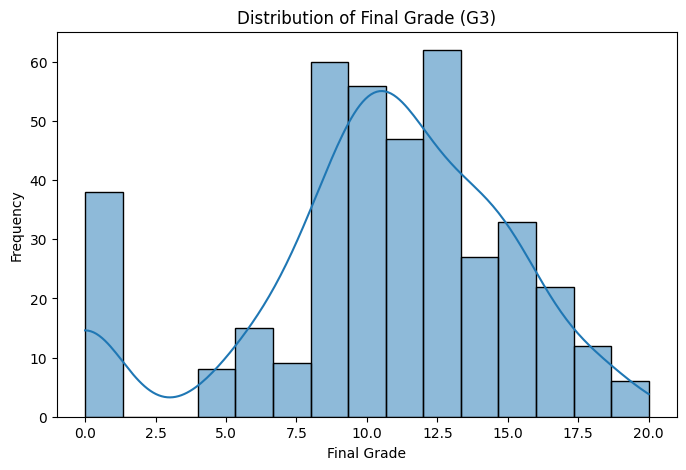

In [19]:
plt.figure(figsize=(8, 5))
sns.histplot(df["G3"], bins=15, kde=True)
plt.title("Distribution of Final Grade (G3)")
plt.xlabel("Final Grade")
plt.ylabel("Frequency")
plt.show()

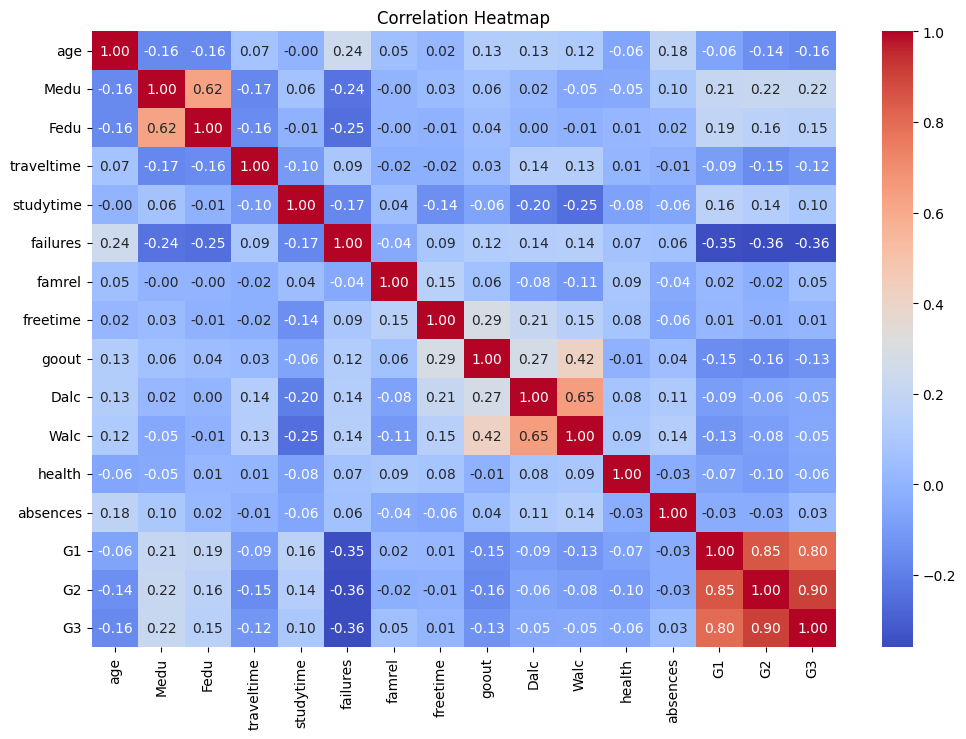

In [20]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

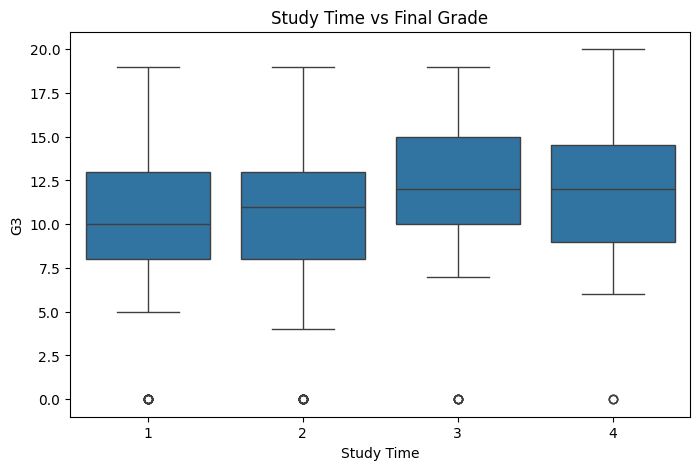

In [21]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="studytime", y="G3", data=df)
plt.title("Study Time vs Final Grade")
plt.xlabel("Study Time")
plt.ylabel("G3")
plt.show()

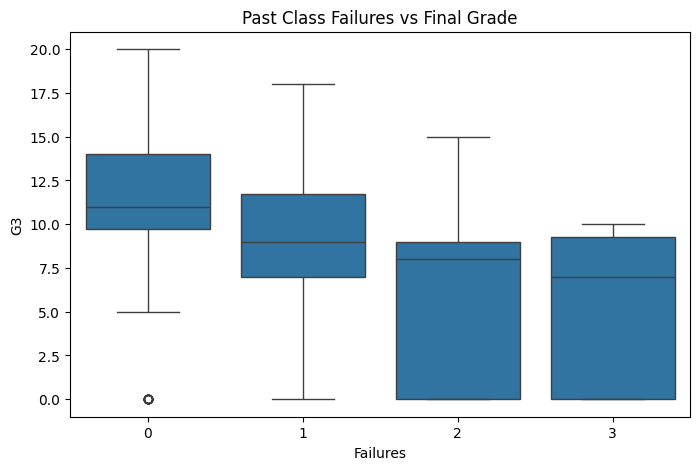

In [22]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="failures", y="G3", data=df)
plt.title("Past Class Failures vs Final Grade")
plt.xlabel("Failures")
plt.ylabel("G3")
plt.show()

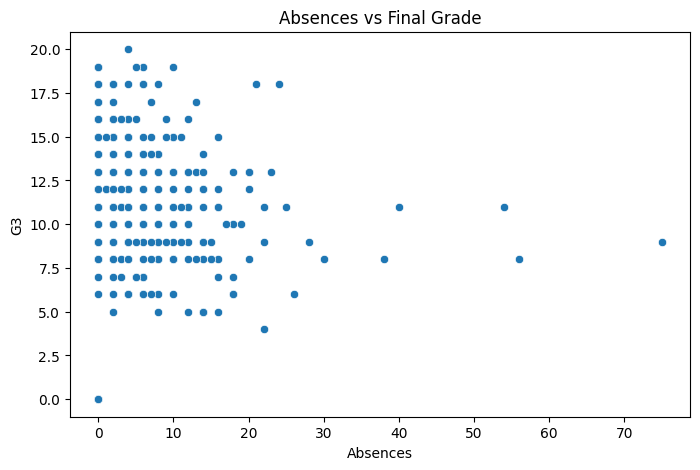

In [23]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="absences", y="G3", data=df)
plt.title("Absences vs Final Grade")
plt.xlabel("Absences")
plt.ylabel("G3")
plt.show()

## 3. Мәліметтерді өңдеу

Бұл кезеңде:
- Target пен feature бөлеміз
- Категориялық бағандарды кодтаймыз
- Сандық бағандарды масштабтаймыз

In [24]:
X = df.drop("G3", axis=1)
y = df["G3"]

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("\nNumerical columns:", numerical_cols)

Categorical columns: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

Numerical columns: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (316, 32)
X_test shape: (79, 32)


In [26]:
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
])

## 4. Модельдерді оқыту

Бұл жобада 2 модель қолданылды:
1. Linear Regression
2. Random Forest

In [27]:
lr_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

In [28]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=200, random_state=42))
])

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

In [29]:
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"----- {model_name} -----")
    print(f"MAE  : {mae:.3f}")
    print(f"MSE  : {mse:.3f}")
    print(f"RMSE : {rmse:.3f}")
    print(f"R2   : {r2:.3f}")
    print()

    return [model_name, mae, mse, rmse, r2]

In [30]:
lr_results = evaluate_model(y_test, lr_pred, "Linear Regression")
rf_results = evaluate_model(y_test, rf_pred, "Random Forest Regressor")

----- Linear Regression -----
MAE  : 1.647
MSE  : 5.657
RMSE : 2.378
R2   : 0.724

----- Random Forest Regressor -----
MAE  : 1.201
MSE  : 4.060
RMSE : 2.015
R2   : 0.802



In [31]:
results_df = pd.DataFrame(
    [lr_results, rf_results],
    columns=["Model", "MAE", "MSE", "RMSE", "R2 Score"]
)

results_df

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,1.646666,5.656643,2.378370,0.724134
1,Random Forest Regressor,1.200506,4.060087,2.014966,0.801996


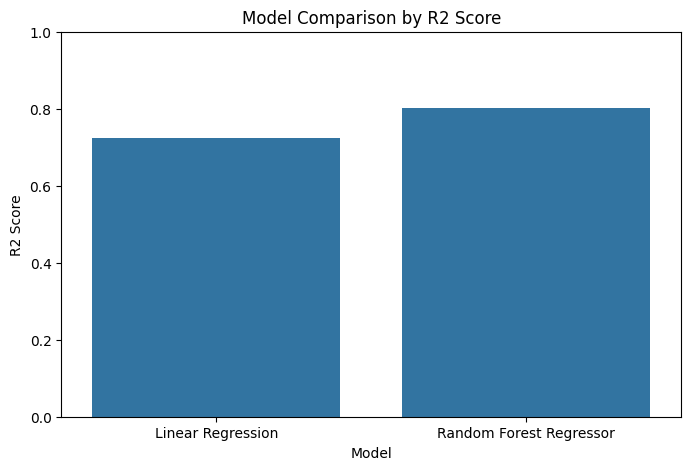

In [32]:
plt.figure(figsize=(8, 5))
sns.barplot(x="Model", y="R2 Score", data=results_df)
plt.title("Model Comparison by R2 Score")
plt.ylim(0, 1)
plt.show()

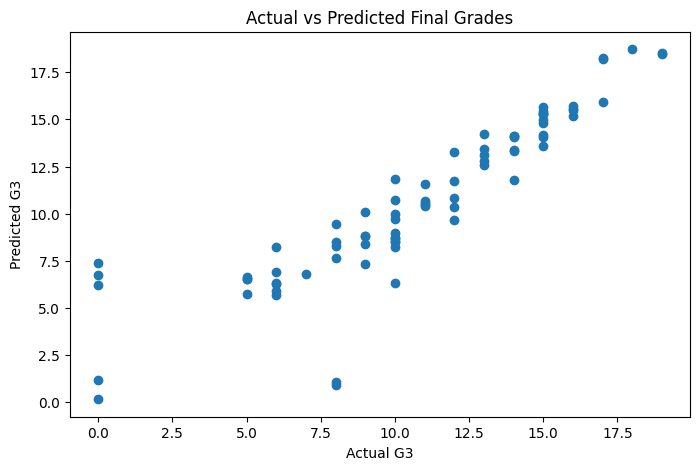

In [33]:
best_pred = rf_pred  # change if Linear Regression performs better

plt.figure(figsize=(8, 5))
plt.scatter(y_test, best_pred)
plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Actual vs Predicted Final Grades")
plt.show()

In [34]:
# Fit preprocessor separately to get transformed feature names
X_train_transformed = preprocessor.fit_transform(X_train)

encoded_cat_names = preprocessor.named_transformers_["cat"]["onehot"].get_feature_names_out(categorical_cols)
all_feature_names = numerical_cols + list(encoded_cat_names)

rf_only = RandomForestRegressor(n_estimators=200, random_state=42)
rf_only.fit(X_train_transformed, y_train)

importances = rf_only.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False).head(15)

feature_importance_df

,Feature,Importance
14,G2,0.787204
12,absences,0.114331
36,reason_home,0.018982
0,age,0.009070
13,G1,0.005542
6,famrel,0.004970
11,health,0.004063
40,guardian_mother,0.003701
8,goout,0.003611
4,studytime,0.003205


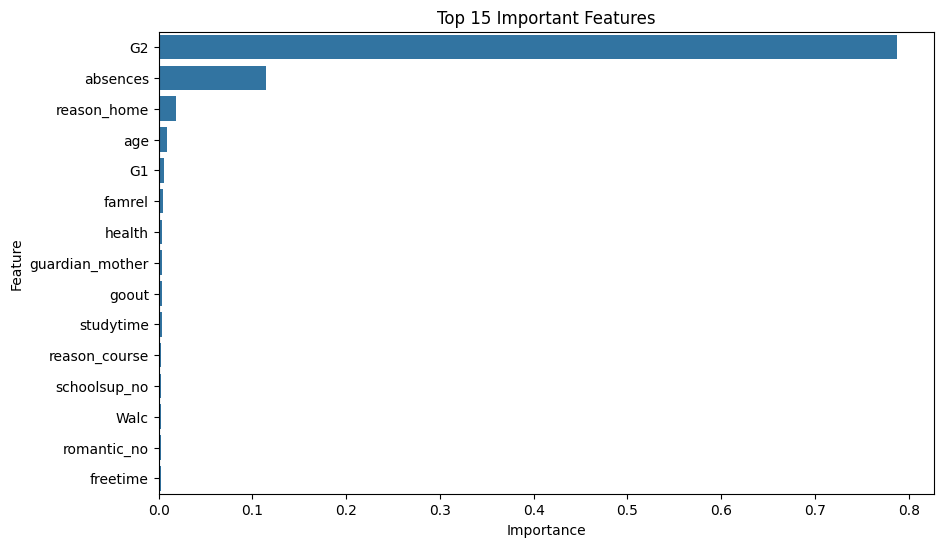

In [35]:
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=feature_importance_df)
plt.title("Top 15 Important Features")
plt.show()

## 5. Қорытынды

Бұл жобада:
- Студенттердің үлгерімі болжау үшін ML қолданылды
- Мәліметтер өңделді және талданды
- 2 модель салыстырылды

### Нәтиже:
Random Forest моделі көбінесе жақсы нәтиже көрсетті.

### Жалпы қорытынды:
Студенттің үлгерімі оқу уақыты, қатысу және басқа факторларға байланысты екенін байқауға болады.